# 1. Import Libraries

In [74]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

import regex as re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

from wordcloud import WordCloud

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import pickle

In [3]:
df = pd.read_csv('dataset_tiktok-comments-scraper_2025-11-17_12-14-29-915.csv')
df.head()

,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,videoWebUrl,uid,cid,avatarThumbnail
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,977,2025-10-09T03:10:07.000Z,ikmalbhrlm,https://www.tiktok.com/@dj_donny/video/7559032...,6962567982649541633,7559053960901559058,https://p19-common-sign.tiktokcdn-us.com/tos-a...
1,buku panduan,49090,185,2025-10-09T05:09:12.000Z,bang.kholis96,https://www.tiktok.com/@dj_donny/video/7559032...,7384053991606486022,7559084636891480853,https://p16-common-sign.tiktokcdn-us.com/tos-a...
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,105,2025-10-09T05:47:57.000Z,user4444_119,https://www.tiktok.com/@dj_donny/video/7559032...,6962785913933235202,7559094616738661121,https://p16-common-sign.tiktokcdn-us.com/tos-a...
3,kok mirip ya😹,14029,134,2025-10-09T05:04:40.000Z,symfahri3,https://www.tiktok.com/@dj_donny/video/7559032...,6632464555773607937,7559083478210904849,https://p16-common-sign.tiktokcdn-us.com/tos-a...
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,60,2025-10-09T02:23:03.000Z,whyfirmann,https://www.tiktok.com/@dj_donny/video/7559032...,6991736734669325314,7559041842743132936,https://p16-common-sign.tiktokcdn-us.com/tos-a...


In [4]:
df.drop(columns=['uniqueId','videoWebUrl','uid','cid','avatarThumbnail','replyCommentTotal'],inplace=True)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1942 non-null   object
 1   diggCount      2000 non-null   int64 
 2   createTimeISO  2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


In [7]:
df.dropna(inplace=True)

In [8]:
df.head()

,text,diggCount,createTimeISO
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09T03:10:07.000Z
1,buku panduan,49090,2025-10-09T05:09:12.000Z
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09T05:47:57.000Z
3,kok mirip ya😹,14029,2025-10-09T05:04:40.000Z
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09T02:23:03.000Z


In [9]:
df['createTimeISO'] = pd.to_datetime(df['createTimeISO'])
df.head()

,text,diggCount,createTimeISO
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09 03:10:07+00:00
1,buku panduan,49090,2025-10-09 05:09:12+00:00
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09 05:47:57+00:00
3,kok mirip ya😹,14029,2025-10-09 05:04:40+00:00
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09 02:23:03+00:00


In [10]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F700-\U0001F77F"  # alchemical
    "\U0001F780-\U0001F7FF"  # geometric extended
    "\U0001F800-\U0001F8FF"  # supplemental arrows
    "\U0001F900-\U0001F9FF"  # supplemental symbols + pictographs
    "\U0001FA00-\U0001FA6F"  # chess, symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "\U00002700-\U000027BF"  # dingbats
    "\U00002600-\U000026FF"  # misc symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

# Scan your DataFrame column
# 1. Collect emojis per row WITHOUT adding a new DataFrame column
emoji_pattern = re.compile(r"\X", flags=re.UNICODE)

# Function to extract only emojis (single grapheme clusters)
def extract_emojis(text):
    chars = emoji_pattern.findall(text)
    return [c for c in chars if any(ord(x) > 1000 for x in c)]  # filters out non-emoji

# If the notebook or previous run created `df['emojis']`, drop it now to avoid keeping it
if 'emojis' in df.columns:
    df.drop(columns=['emojis'], inplace=True)

# Use a local Series to avoid adding a new column
emojis_per_row = df['text'].astype(str).apply(extract_emojis)

# 2. Count emoji presence per row (unique per row)
emoji_row_counts = {}

for emoji_list_row in emojis_per_row:
    unique_in_row = set(emoji_list_row)
    for e in unique_in_row:
        emoji_row_counts[e] = emoji_row_counts.get(e, 0) + 1

# 3. Build stats DataFrame
emoji_stats = pd.DataFrame([
    {
        "emoji": e,
        "rows_with_emoji": count,
        "percentage_of_rows": round((count / len(df)) * 100, 4),
    }
    for e, count in emoji_row_counts.items()
])

emoji_stats = emoji_stats.sort_values("rows_with_emoji", ascending=False)

# Keep only frequently observed emojis (more than 5 rows), without writing them to df
emoji_stats = emoji_stats[emoji_stats['rows_with_emoji'] > 5].reset_index(drop=True)
emoji_list = list(emoji_stats['emoji'])

# Print summary for quick inspection
emoji_list

['🤣',
 '🗿',
 '😂',
 '😭',
 '😁',
 '😹',
 '😏',
 '🔥',
 '🙏',
 '✅',
 '👍',
 '😅',
 '🤭',
 '🥰',
 '❌',
 '😡',
 '😌',
 '🥺',
 '❎',
 '😆']

In [11]:
# RoBERTa Sentiment Analysis Functions

# Load RoBERTa model (using a public alternative)
tokenizer = AutoTokenizer.from_pretrained("w11wo/indonesian-roberta-base-sentiment-classifier")
model = AutoModelForSequenceClassification.from_pretrained("w11wo/indonesian-roberta-base-sentiment-classifier")
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Expanded slang dictionary for better normalization of informal Indonesian text
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "ngak": "tidak",
    "tdk": "tidak",

    "bgt": "banget",

    "bener": "benar",
    "bnr": "benar",

    "bkn": "bukan",

    "bgus": "bagus",
    "bagus": "bagus",
    "keren": "bagus",
    "mantap": "bagus",

    "mantul": "mantap",
    "mantapjiwa": "mantap",

    "jelek": "jelek",

    "asik": "asyik",
    "asyik": "asyik",

    "oke": "baik",
    "ok": "baik",
    "okey": "baik",

    "iya": "ya",
    "ya": "ya",
    "yah": "ya",
    "sih": "ya",

    "syg": "sayang",
    "sayang": "sayang",

    "kk": "kakak",
    "kak": "kakak",
    "mbak": "kakak",
    "mas": "kakak",
    "abang": "abang",

    "sis": "saudara perempuan",
    "bro": "teman",
    "temen": "teman",
    "teman": "teman",

    "gue": "saya",
    "gw": "saya",
    "aku": "saya",

    "lu": "kamu",
    "lo": "kamu",
    "kamu": "kamu",
    "kmu": "kamu",

    "kalo": "kalau",
    "klo": "kalau",
    "kalau": "kalau",

    "gmn": "gimana",
    "gmna": "gimana",
    "gimana": "gimana",

    "dgn": "dengan",
    "dr": "dari",
    "yg": "yang",
    "sbg": "sebagai",

    "saja": "saja",

    "udh": "sudah",
    "udah": "sudah",
    "sdh": "sudah",

    "blm": "belum",
    "belom": "belum",

    "pls": "tolong",
    "tolong": "tolong",

    "makasih": "terima kasih",
    "mks": "terima kasih",
    "makaci": "terima kasih",
    "makasihh": "terima kasih",
    "thanks": "terima kasih",
    "thx": "terima kasih",
    "ty": "terima kasih",

    "kmrn": "kemarin",
    "skrg": "sekarang",
    "bsk": "besok",
    "ntr": "nanti",

    "jgn": "jangan",
    "jgnlah": "jangan",

    "cm": "cuma",
    "cuma": "cuma",
    "cuman": "cuma",

    "bentar": "sebentar",
    "bntr": "sebentar",
    "brb": "sebentar",

    "tpi": "tapi",
    "tp": "tapi",

    "krn": "karena",

    "bales": "balas",
    "balesin": "balas",

    "mnrt": "menurut",

    "sr": "sore",

    "yaudahlah": "ya sudah",

    "omg": "waduh",
    "gws": "semoga cepat sembuh",

    "gg": "good game",

    "btw": "ngomong-ngomong",
    "sm": "sama",
    "smn": "samaan",
    "trus": "terus",
    "trs": "terus",
    "lg": "lagi",
    "lgi": "lagi",
    "pdhl": "padahal",
    "pd": "pada",
    "td": "tadi",
    "tadi2": "tadi",
    "ngap": "mengapa",
    "knp": "kenapa",
    "kenapa": "kenapa",
    "bbrp": "beberapa",
    "ttp": "tetap",

    "wkwk": "tertawa",
    "wkwkwk": "tertawa",
    "haha": "tertawa",
    "hehe": "tertawa",
    "lol": "tertawa",
    "rofl": "tertawa",

    "nt": "nice try",
    "ez": "mudah",
    "idk": "saya tidak tahu",
    "imo": "menurut saya",
    "imho": "menurut saya",
    "cmiiw": "koreksi kalau saya salah",
    "otw": "sedang dalam perjalanan",
    "oot": "di luar topik",
    "asl": "umur jenis kelamin lokasi",
    "jk": "cuma bercanda",

    "anj": "anjing",
    "anjay": "anjing",
    "anjir": "anjing",
    "anjrit": "anjing",
    "anjass": "anjing",

    "baper": "bawa perasaan",
    "kepo": "ingin tahu",
    "mager": "malas gerak",
    "woles": "santai",
    "alay": "norak",
    "php": "pemberi harapan palsu",
    "fomo": "takut ketinggalan",
    "flexing": "pamer",
    "ghosting": "menghilang tanpa kabar",
    "hbd": "selamat ulang tahun",
    "yolo": "hidup cuma sekali",

    "gan": "teman",
    "agan": "teman",
    "mimin": "admin",
    "cupu": "kurang mahir",
    "pdkt": "pendekatan",

    "noob": "pemula",
    "newbie": "pemula",
    "mabar": "main bareng",
    "bot": "pemain buruk",
    "wibu": "penggemar budaya jepang",
    "camp": "bertahan di satu tempat",
    "rush": "serangan cepat",

    "bae": "kesayangan",
    "bucin": "budak cinta",
    "gokil": "gila keren",
    "hf": "bersenang-senang",
    "gl": "semoga berhasil",

    "ig": "instagram"
}


def clean_text(text):
    if pd.isna(text) or text.strip() == "":
        return ""
    text = text.lower()
    # Normalize repeated characters (e.g., "bangetttt" -> "banget") using proper backreferences
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # Preserve emojis as they are critical sentiment signals in informal text like TikTok comments
    # Include emojis from emoji_list (those appearing in >5 rows)
    allowed_emojis = ''.join(emoji_list) if 'emoji_list' in globals() else ""
    allowed_chars = r"\w\s.!?#" + allowed_emojis
    text = re.sub(r"[^" + allowed_chars + r"]", " ", text)
    return text.strip()

def normalize_slang(text, slang_dict):
    if not text:
        return ""
    return " ".join([slang_dict.get(w, w) for w in text.split()])

def predict_roberta(text):
    if not text.strip():
        return "neutral", 0.0
    result = sentiment_pipeline(text)[0]
    return result["label"], float(result["score"])

Device set to use cpu


In [12]:
# Apply RoBERTa preprocessing and prediction
df['cleaned_text'] = df['text'].apply(clean_text)
df['normalized_text'] = df['cleaned_text'].apply(lambda x: normalize_slang(x, slang_dict))

# Predict sentiment using RoBERTa on normalized text (no stemming needed for transformer models with subword tokenization)
df['roberta_label'], df['roberta_score'] = zip(*df['normalized_text'].apply(predict_roberta))

# Categorize RoBERTa sentiment (binary: only positive or negative)
def categorize_roberta(label):
    if 'positive' in label.lower() or 'LABEL_1' in label:
        return 'positive'
    elif 'negative' in label.lower() or 'LABEL_0' in label:
        return 'negative'
    else:
        # Map neutral to positive (you can change to 'negative' if preferred)
        return 'negative'

df['roberta_sentiment'] = df['roberta_label'].apply(categorize_roberta)

In [13]:
df.head()

,text,diggCount,createTimeISO,cleaned_text,normalized_text,roberta_label,roberta_score,roberta_sentiment
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09 03:10:07+00:00,setiap bahlil ngomong kiamat maju 1jam,setiap bahlil ngomong kiamat maju 1jam,neutral,0.976646,negative
1,buku panduan,49090,2025-10-09 05:09:12+00:00,buku panduan,buku panduan,positive,0.551686,positive
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09 05:47:57+00:00,kayaknya si bahlil terinspirasi dari karakter ...,kayaknya si bahlil terinspirasi dari karakter ...,positive,0.997089,positive
3,kok mirip ya😹,14029,2025-10-09 05:04:40+00:00,kok mirip ya😹,kok mirip ya😹,negative,0.817127,negative
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09 02:23:03+00:00,campuran etanol 10 . korupsinya berapa persen? 🤣,campuran etanol 10 . korupsinya berapa persen? 🤣,negative,0.999304,negative


In [14]:
df[df['roberta_score'] <=.65].sort_values(by='roberta_score', ascending=False).head(25)

,text,diggCount,createTimeISO,cleaned_text,normalized_text,roberta_label,roberta_score,roberta_sentiment
1129,mentrinya dari jaman jokowhy,0,2025-11-06 00:07:13+00:00,mentrinya dari jaman jokowhy,mentrinya dari jaman jokowhy,neutral,0.649124,negative
1850,ramah lingkungan tapi tidak rama sama mesin ke...,1,2025-10-14 02:14:01+00:00,ramah lingkungan tapi tidak rama sama mesin ke...,ramah lingkungan tapi tidak rama sama mesin ke...,negative,0.645921,negative
307,"mewakilkan masyarakat sekali lu bang , menyala 🔥",2,2025-10-15 13:02:25+00:00,mewakilkan masyarakat sekali lu bang menyala 🔥,mewakilkan masyarakat sekali kamu bang menyala 🔥,negative,0.645921,negative
1210,coba aja motor BAPAK BAHLIL di isi pertalite j...,0,2025-11-01 12:27:45+00:00,coba aja motor bapak bahlil di isi pertalite j...,coba aja motor bapak bahlil di isi pertalite j...,negative,0.645459,negative
500,kita campur bayar bensin duitnya 10% daun keri...,3,2025-10-09 23:15:17+00:00,kita campur bayar bensin duitnya 10 daun keri...,kita campur bayar bensin duitnya 10 daun kerin...,negative,0.644342,negative
805,ni orang cocok jadi presiden Bangladesh,2,2025-10-09 09:36:18+00:00,ni orang cocok jadi presiden bangladesh,ni orang cocok jadi presiden bangladesh,positive,0.642379,positive
1729,di luar udah sedikit yang pake 2 tak lil bahli...,1,2025-10-14 12:39:40+00:00,di luar udah sedikit yang pake 2 tak lil bahli...,di luar sudah sedikit yang pake 2 tak lil bahl...,negative,0.640358,negative
66,maaf lepas🙏🙏🙏,1853,2025-10-13 09:28:21+00:00,maaf lepas🙏🙏,maaf lepas🙏🙏,negative,0.640173,negative
1994,gua pindah aja bang ke malaysia😄😄,1,2025-10-12 08:43:46+00:00,gua pindah aja bang ke malaysia,gua pindah aja bang ke malaysia,neutral,0.638988,negative
372,bahlil : intinya rakyat harus tetap sengsara,4,2025-10-09 03:30:26+00:00,bahlil intinya rakyat harus tetap sengsara,bahlil intinya rakyat harus tetap sengsara,negative,0.638181,negative


In [15]:
df = df[df['roberta_score'] >.65]

In [16]:
df_negative = df[df['roberta_sentiment'] == 'negative']
df_positive = df[df['roberta_sentiment'] == 'positive']

In [17]:
df_positive['normalized_text'].head(25)

2      kayaknya si bahlil terinspirasi dari karakter ...
22                                          untuk bersih
39                                  bahlil bahlul 😂🤣😂🤣😂🤣
45        dukun bahlil kuat benar dah kaga diganti ganti
58     terima kasih bang sudah bantu speak up manusia...
68     bahlil itu belajar nya drimna kok dibilang bgus👍😁
90                                  ❌️bahlil. ✅️bahlul🗿🗿
96                                    bahlil artinya apa
106    tampang kayak gitu kok bisa jadi menteri.terus...
123    saya lebih percaya statement bang fitra eri da...
145    maksud mr bahlil agar kendaraan motor cepat ru...
146                         saking pinternya ke blinger😏
150                                bang semangat terus 🤣
159              kalok bagus.knpa spbu suasta ttup lill.
160                 kalau bagus tidak perlu paksa2 deh..
162                                           si bahlil🗿
172                          bahlil muka nya lucu imut2😅
178      gua kangen nungguin ka

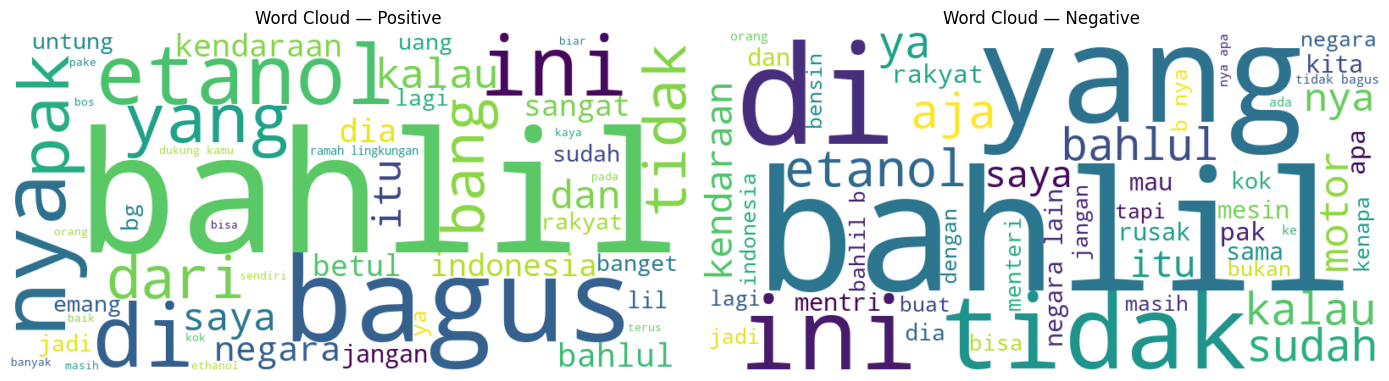

In [18]:
# Word Cloud for Positive and Negative Comments (side-by-side)
# Use `normalized_text` if available, otherwise fall back to `text`
text_col = 'normalized_text' if 'normalized_text' in df.columns else 'text'
# Build the text blobs safely (ensure strings)
negative_text = ' '.join(df_negative[text_col].astype(str)) if not df_negative.empty else ''
positive_text = ' '.join(df_positive[text_col].astype(str)) if not df_positive.empty else ''
# Provide a safe non-empty string to WordCloud.generate() if needed
neg_blob = negative_text if negative_text.strip() else ' '
pos_blob = positive_text if positive_text.strip() else ' '
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(neg_blob)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(pos_blob)

plt.figure(figsize=(14, 6))
# Positive on the left
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Positive')
# Negative on the right
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Negative')
plt.tight_layout()
plt.show()

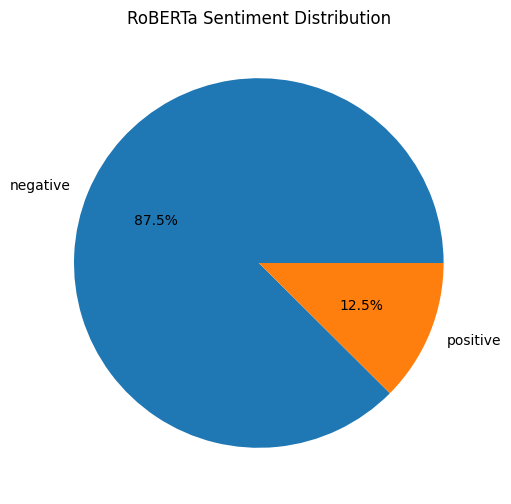

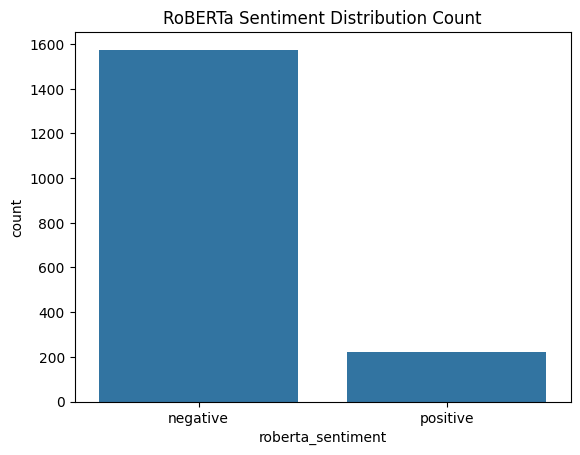

In [19]:
# Additional RoBERTa Visualizations

# Pie chart for RoBERTa labels
df['roberta_sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('RoBERTa Sentiment Distribution')
plt.ylabel('')
plt.show()

sns.countplot(x=df['roberta_sentiment'])
plt.title('RoBERTa Sentiment Distribution Count')
plt.show()

In [20]:
df.to_csv("Data After Preprocess.csv")

# Sum diggCount per sentiment and show a bar chart

In [21]:
# Ensure diggCount is numeric
df['diggCount'] = pd.to_numeric(df['diggCount'], errors='coerce').fillna(0).astype(int)

sent_col = df['roberta_sentiment']
sums = df.groupby(sent_col)['diggCount'].sum().reset_index().rename(columns={'diggCount':'total_digg'})

# Sort to show highest first
sums = sums.sort_values('total_digg', ascending=False)
print('Total diggCount per sentiment:')
print(sums.to_string(index=False))

Total diggCount per sentiment:
roberta_sentiment  total_digg
         negative      200450
         positive       17957


In [22]:
sums

,roberta_sentiment,total_digg
0,negative,200450
1,positive,17957


In [23]:
df.sort_values('diggCount', ascending=False).head(25)

,text,diggCount,createTimeISO,cleaned_text,normalized_text,roberta_label,roberta_score,roberta_sentiment
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09 03:10:07+00:00,setiap bahlil ngomong kiamat maju 1jam,setiap bahlil ngomong kiamat maju 1jam,neutral,0.976646,negative
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09 02:23:03+00:00,campuran etanol 10 . korupsinya berapa persen? 🤣,campuran etanol 10 . korupsinya berapa persen? 🤣,negative,0.999304,negative
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09 05:47:57+00:00,kayaknya si bahlil terinspirasi dari karakter ...,kayaknya si bahlil terinspirasi dari karakter ...,positive,0.997089,positive
126,tiap bahlil ngomong kiamat maju 1 jam,15524,2025-10-10 09:43:39+00:00,tiap bahlil ngomong kiamat maju 1 jam,tiap bahlil ngomong kiamat maju 1 jam,negative,0.709954,negative
3,kok mirip ya😹,14029,2025-10-09 05:04:40+00:00,kok mirip ya😹,kok mirip ya😹,negative,0.817127,negative
99,PAK PRABOWO TOLONG GANTI BAHLIL😩 apalah ini pe...,8872,2025-10-09 03:58:03+00:00,pak prabowo tolong ganti bahlil apalah ini pe...,pak prabowo tolong ganti bahlil apalah ini per...,neutral,0.998480,negative
5,bayar pajaknya boleh campur pake daun singkong?,5802,2025-10-09 05:32:20+00:00,bayar pajaknya boleh campur pake daun singkong?,bayar pajaknya boleh campur pake daun singkong?,neutral,0.992048,negative
130,pecat menti satu ini.. muak liatnya..,5493,2025-10-10 04:40:35+00:00,pecat menti satu ini.. muak liatnya..,pecat menti satu ini.. muak liatnya..,negative,0.999465,negative
128,buktinya Shell dan Vivo gak mau beli.,5368,2025-10-10 04:08:48+00:00,buktinya shell dan vivo gak mau beli.,buktinya shell dan vivo tidak mau beli.,negative,0.998675,negative
10,ko bisa jadi menteri,4464,2025-10-09 01:58:17+00:00,ko bisa jadi menteri,ko bisa jadi menteri,neutral,0.993598,negative


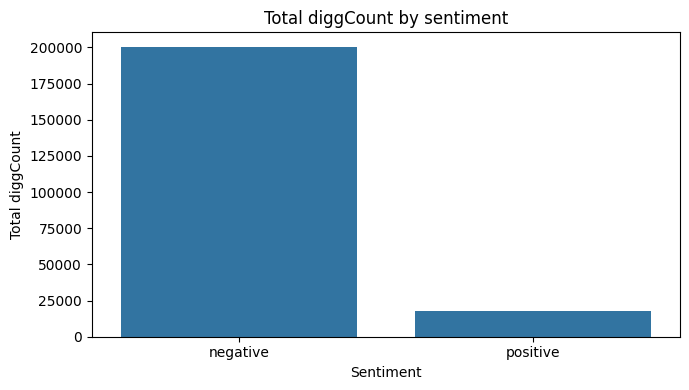

In [24]:
# Plotting
plt.figure(figsize=(7,4))
sns.barplot(x=sums['roberta_sentiment'], y=sums['total_digg'])
plt.title('Total diggCount by sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Total diggCount')
plt.tight_layout()
plt.show()

In [25]:
label_maps = {
    'positive':1,
    'negative':0
}

df['roberta_label'] = df['roberta_label'].map(label_maps)
df['roberta_sentiment'] = df['roberta_sentiment'].map(label_maps)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1799 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   text               1799 non-null   object             
 1   diggCount          1799 non-null   int64              
 2   createTimeISO      1799 non-null   datetime64[ns, UTC]
 3   cleaned_text       1799 non-null   object             
 4   normalized_text    1799 non-null   object             
 5   roberta_label      1408 non-null   float64            
 6   roberta_score      1799 non-null   float64            
 7   roberta_sentiment  1799 non-null   int64              
dtypes: datetime64[ns, UTC](1), float64(2), int64(2), object(3)
memory usage: 126.5+ KB


In [27]:
df_ready =  df.drop(columns=['roberta_score','roberta_label'])

In [28]:
df.to_csv("Data After Preprocess")

## Stratified split, Random Forest training and evaluation
We will perform a stratified split on `df_ready` using `indobert_label` as the label, with a 70/15/15 train/val/test ratio. After that we use TF-IDF features and train a `RandomForestClassifier` and evaluate on validation and test sets.

In [29]:
# df_ready must contain the text column (normalized_text is preferred) and the label `roberta_label`
text_col = 'normalized_text' if 'normalized_text' in df_ready.columns else ('cleaned_text' if 'cleaned_text' in df_ready.columns else 'text')
label_col = 'roberta_label' if 'roberta_label' in df_ready.columns else ('roberta_sentiment' if 'roberta_sentiment' in df_ready.columns else None)
assert label_col is not None, 'No label column found in df_ready; expected roberta_label or roberta_sentiment'
X = df_ready[text_col].astype(str).values
y = df_ready[label_col].values

In [30]:
# First split: hold out test set (15%) stratified
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
# Second split: split the remaining 85% into train and val with val about 15% of original -> test_size = 0.15/0.85
val_fraction = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_fraction, stratify=y_train_val, random_state=42)
# Print sizes
print(f'Original: {len(X)} rows')
print(f'Train: {len(X_train)} ({len(X_train)/len(X):.2%})')
print(f'Validation: {len(X_val)} ({len(X_val)/len(X):.2%})')
print(f'Test: {len(X_test)} ({len(X_test)/len(X):.2%})')

Original: 1799 rows
Train: 1259 (69.98%)
Validation: 270 (15.01%)
Test: 270 (15.01%)


In [31]:
# Train RandomForest on training set and evaluate on validation set
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [32]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_val_pred = rf.predict(X_val_tfidf)
print('Validation set results:')
print(classification_report(y_val, y_val_pred))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred))

Validation set results:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       236
           1       0.38      0.32      0.35        34

    accuracy                           0.85       270
   macro avg       0.64      0.62      0.63       270
weighted avg       0.84      0.85      0.84       270

Confusion matrix (validation):
[[218  18]
 [ 23  11]]
Validation accuracy: 0.8481481481481481


In [33]:
# Retrain final model on train+val and evaluate on test set
# Fit new TF-IDF on combined train+val so it sees those features too
vectorizer_final = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_val_tfidf = vectorizer_final.fit_transform(X_train_val)
X_test_tfidf = vectorizer_final.transform(X_test)
rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_final.fit(X_train_val_tfidf, y_train_val)
y_test_pred = rf_final.predict(X_test_tfidf)

In [34]:
print('Test set results (final model trained on train+val):')
print(classification_report(y_test, y_test_pred))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred))
print('Test accuracy:', accuracy_score(y_test, y_test_pred))

Test set results (final model trained on train+val):
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       236
           1       0.57      0.38      0.46        34

    accuracy                           0.89       270
   macro avg       0.74      0.67      0.70       270
weighted avg       0.87      0.89      0.88       270

Confusion matrix (test):
[[226  10]
 [ 21  13]]
Test accuracy: 0.8851851851851852


In [35]:
# Hyperparameter tuning for RandomForest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, cv=3, scoring='f1')
grid_rf.fit(X_train_val_tfidf, y_train_val)
print('Best params for RF:', grid_rf.best_params_)
rf_tuned = grid_rf.best_estimator_
y_test_pred_rf_tuned = rf_tuned.predict(X_test_tfidf)
print('Tuned RF Test set results:')
print(classification_report(y_test, y_test_pred_rf_tuned, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_rf_tuned))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_rf_tuned))

Best params for RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned RF Test set results:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       236
           1       0.57      0.38      0.46        34

    accuracy                           0.89       270
   macro avg       0.74      0.67      0.70       270
weighted avg       0.87      0.89      0.88       270

Confusion matrix (test):
[[226  10]
 [ 21  13]]
Test accuracy: 0.8851851851851852


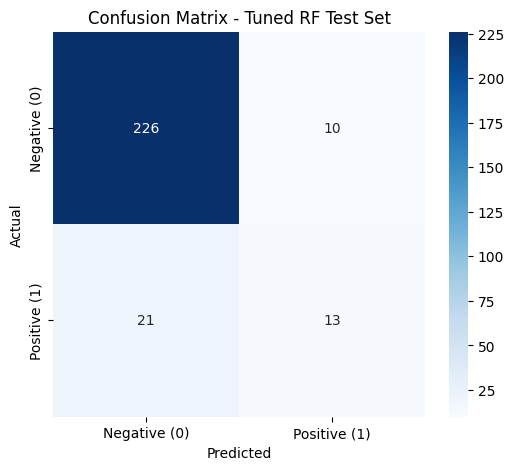

In [36]:
# Visualize the confusion matrix for the test set
cm = confusion_matrix(y_test, y_test_pred_rf_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Tuned RF Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
# Apply SMOTE to balance training data for RF

# SMOTE on train set for validation evaluation
smote_rf = SMOTE(random_state=42)
X_train_sm_rf, y_train_sm_rf = smote_rf.fit_resample(X_train_tfidf, y_train)
print(f"Original train: {len(y_train)} samples, SMOTE train: {len(y_train_sm_rf)} samples")
print(f"SMOTE train class distribution: {np.bincount(y_train_sm_rf)}")

# Train RF on SMOTE data
rf_sm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_sm.fit(X_train_sm_rf, y_train_sm_rf)
y_val_pred_rf_sm = rf_sm.predict(X_val_tfidf)
print('RF with SMOTE Validation set results:')
print(classification_report(y_val, y_val_pred_rf_sm, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_rf_sm))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_rf_sm))


Original train: 1259 samples, SMOTE train: 2206 samples
SMOTE train class distribution: [1103 1103]
RF with SMOTE Validation set results:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       236
           1       0.37      0.41      0.39        34

    accuracy                           0.84       270
   macro avg       0.64      0.66      0.65       270
weighted avg       0.85      0.84      0.84       270

Confusion matrix (validation):
[[212  24]
 [ 20  14]]
Validation accuracy: 0.837037037037037


In [38]:
# SMOTE on train+val for final model
X_train_val_sm_rf, y_train_val_sm_rf = smote_rf.fit_resample(X_train_val_tfidf, y_train_val)
print(f"\nOriginal train+val: {len(y_train_val)} samples, SMOTE train+val: {len(y_train_val_sm_rf)} samples")

# Retrain final RF on SMOTE data
rf_final_sm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_final_sm.fit(X_train_val_sm_rf, y_train_val_sm_rf)
y_test_pred_rf_sm = rf_final_sm.predict(X_test_tfidf)
print('RF with SMOTE Test set results (final model):')
print(classification_report(y_test, y_test_pred_rf_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_rf_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_rf_sm))



Original train+val: 1529 samples, SMOTE train+val: 2678 samples
RF with SMOTE Test set results (final model):
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       236
           1       0.41      0.56      0.47        34

    accuracy                           0.84       270
   macro avg       0.67      0.72      0.69       270
weighted avg       0.87      0.84      0.85       270

Confusion matrix (test):
[[209  27]
 [ 15  19]]
Test accuracy: 0.8444444444444444


In [39]:

# Hyperparameter tuning with SMOTE
grid_rf_sm = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, cv=3, scoring='f1')
grid_rf_sm.fit(X_train_val_sm_rf, y_train_val_sm_rf)
print('Best params for RF with SMOTE:', grid_rf_sm.best_params_)
rf_tuned_sm = grid_rf_sm.best_estimator_
y_test_pred_rf_tuned_sm = rf_tuned_sm.predict(X_test_tfidf)
print('Tuned RF with SMOTE Test set results:')
print(classification_report(y_test, y_test_pred_rf_tuned_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_rf_tuned_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_rf_tuned_sm))

Best params for RF with SMOTE: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Tuned RF with SMOTE Test set results:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       236
           1       0.42      0.56      0.48        34

    accuracy                           0.85       270
   macro avg       0.68      0.72      0.70       270
weighted avg       0.87      0.85      0.86       270

Confusion matrix (test):
[[210  26]
 [ 15  19]]
Test accuracy: 0.8481481481481481


In [40]:
# Train SVM on training set and evaluate on validation set
svm = LinearSVC(random_state=42, max_iter=20000, dual=False)
svm.fit(X_train_tfidf, y_train)
y_val_pred_svm = svm.predict(X_val_tfidf)
print('SVM Validation set results:')
print(classification_report(y_val, y_val_pred_svm))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_svm))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_svm))

SVM Validation set results:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       236
           1       0.67      0.18      0.28        34

    accuracy                           0.89       270
   macro avg       0.78      0.58      0.61       270
weighted avg       0.86      0.89      0.85       270

Confusion matrix (validation):
[[233   3]
 [ 28   6]]
Validation accuracy: 0.8851851851851852


In [41]:
# Retrain final SVM model on train+val and evaluate on test set
svm_final = LinearSVC(random_state=42, max_iter=20000, dual=False)
svm_final.fit(X_train_val_tfidf, y_train_val)
y_test_pred_svm = svm_final.predict(X_test_tfidf)
print('SVM Test set results (final model trained on train+val):')
print(classification_report(y_test, y_test_pred_svm))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_svm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_svm))

SVM Test set results (final model trained on train+val):
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       236
           1       0.67      0.12      0.20        34

    accuracy                           0.88       270
   macro avg       0.78      0.55      0.57       270
weighted avg       0.86      0.88      0.84       270

Confusion matrix (test):
[[234   2]
 [ 30   4]]
Test accuracy: 0.8814814814814815


In [42]:
# Hyperparameter tuning for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'loss': ['squared_hinge'],
    'max_iter': [20000],
    'dual': [False]
}
grid_svm = GridSearchCV(LinearSVC(random_state=42), param_grid_svm, cv=3, scoring='f1')
grid_svm.fit(X_train_val_tfidf, y_train_val)
print('Best params for SVM:', grid_svm.best_params_)
svm_tuned = grid_svm.best_estimator_
y_test_pred_svm_tuned = svm_tuned.predict(X_test_tfidf)
print('Tuned SVM Test set results:')
print(classification_report(y_test, y_test_pred_svm_tuned, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_svm_tuned))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_svm_tuned))

Best params for SVM: {'C': 10, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 20000}
Tuned SVM Test set results:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       236
           1       0.44      0.24      0.31        34

    accuracy                           0.87       270
   macro avg       0.67      0.60      0.62       270
weighted avg       0.84      0.87      0.85       270

Confusion matrix (test):
[[226  10]
 [ 26   8]]
Test accuracy: 0.8666666666666667


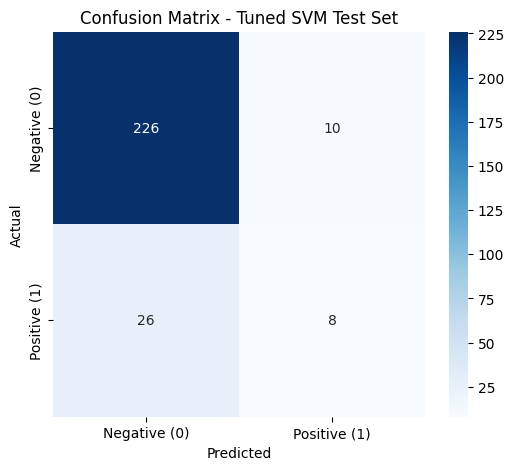

In [43]:
# Visualize the confusion matrix for the test set
cm_svm = confusion_matrix(y_test, y_test_pred_svm_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Tuned SVM Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [44]:
# Apply SMOTE to balance training data for SVM

# SMOTE on train set for validation evaluation
smote_svm = SMOTE(random_state=42)
X_train_sm_svm, y_train_sm_svm = smote_svm.fit_resample(X_train_tfidf, y_train)
print(f"Original train: {len(y_train)} samples, SMOTE train: {len(y_train_sm_svm)} samples")
print(f"SMOTE train class distribution: {np.bincount(y_train_sm_svm)}")

# Train SVM on SMOTE data
svm_sm = LinearSVC(random_state=42, max_iter=20000, dual=False)
svm_sm.fit(X_train_sm_svm, y_train_sm_svm)
y_val_pred_svm_sm = svm_sm.predict(X_val_tfidf)
print('SVM with SMOTE Validation set results:')
print(classification_report(y_val, y_val_pred_svm_sm, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_svm_sm))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_svm_sm))

Original train: 1259 samples, SMOTE train: 2206 samples
SMOTE train class distribution: [1103 1103]
SVM with SMOTE Validation set results:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       236
           1       0.38      0.38      0.38        34

    accuracy                           0.84       270
   macro avg       0.65      0.65      0.65       270
weighted avg       0.84      0.84      0.84       270

Confusion matrix (validation):
[[215  21]
 [ 21  13]]
Validation accuracy: 0.8444444444444444


In [45]:
# SMOTE on train+val for final model
X_train_val_sm_svm, y_train_val_sm_svm = smote_svm.fit_resample(X_train_val_tfidf, y_train_val)
print(f"\nOriginal train+val: {len(y_train_val)} samples, SMOTE train+val: {len(y_train_val_sm_svm)} samples")

# Retrain final SVM on SMOTE data
svm_final_sm = LinearSVC(random_state=42, max_iter=20000, dual=False)
svm_final_sm.fit(X_train_val_sm_svm, y_train_val_sm_svm)
y_test_pred_svm_sm = svm_final_sm.predict(X_test_tfidf)
print('SVM with SMOTE Test set results (final model):')
print(classification_report(y_test, y_test_pred_svm_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_svm_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_svm_sm))


Original train+val: 1529 samples, SMOTE train+val: 2678 samples
SVM with SMOTE Test set results (final model):
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       236
           1       0.42      0.53      0.47        34

    accuracy                           0.85       270
   macro avg       0.67      0.71      0.69       270
weighted avg       0.87      0.85      0.86       270

Confusion matrix (test):
[[211  25]
 [ 16  18]]
Test accuracy: 0.8481481481481481


In [46]:
# Hyperparameter tuning with SMOTE
grid_svm_sm = GridSearchCV(LinearSVC(random_state=42, dual=False), param_grid_svm, cv=3, scoring='f1')
grid_svm_sm.fit(X_train_val_sm_svm, y_train_val_sm_svm)
print('Best params for SVM with SMOTE:', grid_svm_sm.best_params_)
svm_tuned_sm = grid_svm_sm.best_estimator_
y_test_pred_svm_tuned_sm = svm_tuned_sm.predict(X_test_tfidf)
print('Tuned SVM with SMOTE Test set results:')
print(classification_report(y_test, y_test_pred_svm_tuned_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_svm_tuned_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_svm_tuned_sm))

Best params for SVM with SMOTE: {'C': 1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 20000}
Tuned SVM with SMOTE Test set results:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       236
           1       0.42      0.53      0.47        34

    accuracy                           0.85       270
   macro avg       0.67      0.71      0.69       270
weighted avg       0.87      0.85      0.86       270

Confusion matrix (test):
[[211  25]
 [ 16  18]]
Test accuracy: 0.8481481481481481


In [47]:
# Train Logistic Regression on training set and evaluate on validation set
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_val_pred_lr = lr.predict(X_val_tfidf)
print('LR Validation set results:')
print(classification_report(y_val, y_val_pred_lr, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_lr))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_lr))

LR Validation set results:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       236
           1       1.00      0.03      0.06        34

    accuracy                           0.88       270
   macro avg       0.94      0.51      0.50       270
weighted avg       0.89      0.88      0.82       270

Confusion matrix (validation):
[[236   0]
 [ 33   1]]
Validation accuracy: 0.8777777777777778


In [48]:
# Retrain final LR model on train+val and evaluate on test set
lr_final = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_final.fit(X_train_val_tfidf, y_train_val)
y_test_pred_lr = lr_final.predict(X_test_tfidf)
print('LR Test set results (final model trained on train+val):')
print(classification_report(y_test, y_test_pred_lr, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_lr))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_lr))

LR Test set results (final model trained on train+val):
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       236
           1       0.44      0.53      0.48        34

    accuracy                           0.86       270
   macro avg       0.68      0.72      0.70       270
weighted avg       0.87      0.86      0.86       270

Confusion matrix (test):
[[213  23]
 [ 16  18]]
Test accuracy: 0.8555555555555555


In [49]:
# Hyperparameter tuning for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'), param_grid_lr, cv=3, scoring='f1')
grid_lr.fit(X_train_val_tfidf, y_train_val)
print('Best params for LR:', grid_lr.best_params_)
lr_tuned = grid_lr.best_estimator_
y_test_pred_lr_tuned = lr_tuned.predict(X_test_tfidf)
print('Tuned LR Test set results:')
print(classification_report(y_test, y_test_pred_lr_tuned, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_lr_tuned))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_lr_tuned))

Best params for LR: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuned LR Test set results:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       236
           1       0.45      0.50      0.47        34

    accuracy                           0.86       270
   macro avg       0.69      0.71      0.70       270
weighted avg       0.87      0.86      0.86       270

Confusion matrix (test):
[[215  21]
 [ 17  17]]
Test accuracy: 0.8592592592592593


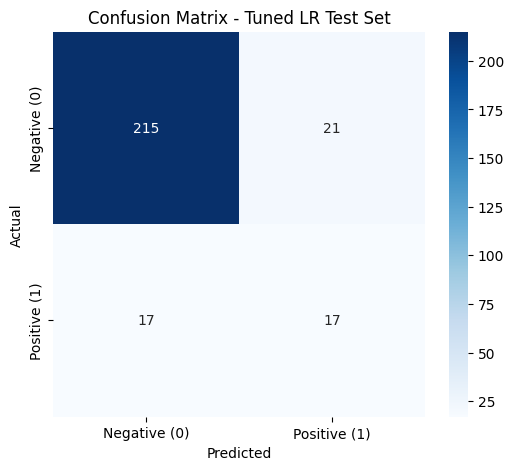

In [50]:
# Visualize the confusion matrix for the test set
cm_lr = confusion_matrix(y_test, y_test_pred_lr_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Tuned LR Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [51]:
# Print class imbalances in training and validation sets
print("Training set class distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    print(f"Class {cls}: {count} ({count / len(y_train):.2%})")

print("\nValidation set class distribution:")
unique_val, counts_val = np.unique(y_val, return_counts=True)
for cls, count in zip(unique_val, counts_val):
    print(f"Class {cls}: {count} ({count / len(y_val):.2%})")

print(f"\nOverall imbalance ratio (negatives:positives): {counts_train[0] / counts_train[1]:.1f}:1 in train, {counts_val[0] / counts_val[1]:.1f}:1 in val")

Training set class distribution:
Class 0: 1103 (87.61%)
Class 1: 156 (12.39%)

Validation set class distribution:
Class 0: 236 (87.41%)
Class 1: 34 (12.59%)

Overall imbalance ratio (negatives:positives): 7.1:1 in train, 6.9:1 in val


In [52]:
# Apply SMOTE to balance training data for LR

# SMOTE on train set for validation evaluation
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
print(f"Original train: {len(y_train)} samples, SMOTE train: {len(y_train_sm)} samples")
print(f"SMOTE train class distribution: {np.bincount(y_train_sm)}")

# SMOTE on train+val for final model
X_train_val_sm, y_train_val_sm = smote.fit_resample(X_train_val_tfidf, y_train_val)
print(f"\nOriginal train+val: {len(y_train_val)} samples, SMOTE train+val: {len(y_train_val_sm)} samples")

Original train: 1259 samples, SMOTE train: 2206 samples
SMOTE train class distribution: [1103 1103]

Original train+val: 1529 samples, SMOTE train+val: 2678 samples


In [53]:
# Train LR on SMOTE data
lr_sm = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_sm.fit(X_train_sm, y_train_sm)
y_val_pred_lr_sm = lr_sm.predict(X_val_tfidf)
print('LR with SMOTE Validation set results:')
print(classification_report(y_val, y_val_pred_lr_sm, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_lr_sm))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_lr_sm))

LR with SMOTE Validation set results:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       236
           1       0.36      0.41      0.38        34

    accuracy                           0.83       270
   macro avg       0.64      0.65      0.64       270
weighted avg       0.84      0.83      0.84       270

Confusion matrix (validation):
[[211  25]
 [ 20  14]]
Validation accuracy: 0.8333333333333334


In [54]:
# Retrain final LR on SMOTE data
lr_final_sm = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_final_sm.fit(X_train_val_sm, y_train_val_sm)
y_test_pred_lr_sm = lr_final_sm.predict(X_test_tfidf)
print('LR with SMOTE Test set results (final model):')
print(classification_report(y_test, y_test_pred_lr_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_lr_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_lr_sm))

LR with SMOTE Test set results (final model):
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       236
           1       0.39      0.53      0.45        34

    accuracy                           0.84       270
   macro avg       0.66      0.71      0.68       270
weighted avg       0.86      0.84      0.85       270

Confusion matrix (test):
[[208  28]
 [ 16  18]]
Test accuracy: 0.837037037037037


In [55]:
# Hyperparameter tuning with SMOTE
grid_lr_sm = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'), param_grid_lr, cv=3, scoring='f1')
grid_lr_sm.fit(X_train_val_sm, y_train_val_sm)
print('Best params for LR with SMOTE:', grid_lr_sm.best_params_)
lr_tuned_sm = grid_lr_sm.best_estimator_
y_test_pred_lr_tuned_sm = lr_tuned_sm.predict(X_test_tfidf)
print('Tuned LR with SMOTE Test set results:')
print(classification_report(y_test, y_test_pred_lr_tuned_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_lr_tuned_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_lr_tuned_sm))

Best params for LR with SMOTE: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuned LR with SMOTE Test set results:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       236
           1       0.39      0.50      0.44        34

    accuracy                           0.84       270
   macro avg       0.66      0.69      0.67       270
weighted avg       0.86      0.84      0.85       270

Confusion matrix (test):
[[209  27]
 [ 17  17]]
Test accuracy: 0.837037037037037


In [56]:
# Train Naive Bayes on training set and evaluate on validation set
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_val_pred_nb = nb.predict(X_val_tfidf)
print('NB Validation set results:')
print(classification_report(y_val, y_val_pred_nb, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_nb))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_nb))

NB Validation set results:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       236
           1       0.00      0.00      0.00        34

    accuracy                           0.87       270
   macro avg       0.44      0.50      0.47       270
weighted avg       0.76      0.87      0.82       270

Confusion matrix (validation):
[[236   0]
 [ 34   0]]
Validation accuracy: 0.8740740740740741


In [57]:
# Retrain final NB model on train+val and evaluate on test set
nb_final = MultinomialNB()
nb_final.fit(X_train_val_tfidf, y_train_val)
y_test_pred_nb = nb_final.predict(X_test_tfidf)
print('NB Test set results (final model trained on train+val):')
print(classification_report(y_test, y_test_pred_nb, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_nb))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_nb))

NB Test set results (final model trained on train+val):
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       236
           1       0.00      0.00      0.00        34

    accuracy                           0.87       270
   macro avg       0.44      0.50      0.47       270
weighted avg       0.76      0.87      0.82       270

Confusion matrix (test):
[[236   0]
 [ 34   0]]
Test accuracy: 0.8740740740740741


In [58]:
# Hyperparameter tuning for Naive Bayes
param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}
grid_nb = GridSearchCV(MultinomialNB(), param_grid_nb, cv=3, scoring='f1')
grid_nb.fit(X_train_val_tfidf, y_train_val)
print('Best params for NB:', grid_nb.best_params_)
nb_tuned = grid_nb.best_estimator_
y_test_pred_nb_tuned = nb_tuned.predict(X_test_tfidf)
print('Tuned NB Test set results:')
print(classification_report(y_test, y_test_pred_nb_tuned, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_nb_tuned))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_nb_tuned))

Best params for NB: {'alpha': 0.1}
Tuned NB Test set results:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       236
           1       1.00      0.09      0.16        34

    accuracy                           0.89       270
   macro avg       0.94      0.54      0.55       270
weighted avg       0.90      0.89      0.84       270

Confusion matrix (test):
[[236   0]
 [ 31   3]]
Test accuracy: 0.8851851851851852


In [59]:
# Apply SMOTE to balance training data for NB

# SMOTE on train set for validation evaluation
smote_nb = SMOTE(random_state=42)
X_train_sm_nb, y_train_sm_nb = smote_nb.fit_resample(X_train_tfidf, y_train)
print(f"Original train: {len(y_train)} samples, SMOTE train: {len(y_train_sm_nb)} samples")
print(f"SMOTE train class distribution: {np.bincount(y_train_sm_nb)}")

# Train NB on SMOTE data
nb_sm = MultinomialNB()
nb_sm.fit(X_train_sm_nb, y_train_sm_nb)
y_val_pred_nb_sm = nb_sm.predict(X_val_tfidf)
print('NB with SMOTE Validation set results:')
print(classification_report(y_val, y_val_pred_nb_sm, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_nb_sm))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_nb_sm))

Original train: 1259 samples, SMOTE train: 2206 samples
SMOTE train class distribution: [1103 1103]
NB with SMOTE Validation set results:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       236
           1       0.53      0.26      0.35        34

    accuracy                           0.88       270
   macro avg       0.72      0.62      0.64       270
weighted avg       0.85      0.88      0.86       270

Confusion matrix (validation):
[[228   8]
 [ 25   9]]
Validation accuracy: 0.8777777777777778


In [60]:
# SMOTE on train+val for final model
X_train_val_sm_nb, y_train_val_sm_nb = smote_nb.fit_resample(X_train_val_tfidf, y_train_val)
print(f"\nOriginal train+val: {len(y_train_val)} samples, SMOTE train+val: {len(y_train_val_sm_nb)} samples")

# Retrain final NB on SMOTE data
nb_final_sm = MultinomialNB()
nb_final_sm.fit(X_train_val_sm_nb, y_train_val_sm_nb)
y_test_pred_nb_sm = nb_final_sm.predict(X_test_tfidf)
print('NB with SMOTE Test set results (final model):')
print(classification_report(y_test, y_test_pred_nb_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_nb_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_nb_sm))


Original train+val: 1529 samples, SMOTE train+val: 2678 samples
NB with SMOTE Test set results (final model):
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       236
           1       0.40      0.24      0.30        34

    accuracy                           0.86       270
   macro avg       0.65      0.59      0.61       270
weighted avg       0.83      0.86      0.84       270

Confusion matrix (test):
[[224  12]
 [ 26   8]]
Test accuracy: 0.8592592592592593


In [61]:
# Hyperparameter tuning with SMOTE
grid_nb_sm = GridSearchCV(MultinomialNB(), param_grid_nb, cv=3, scoring='f1')
grid_nb_sm.fit(X_train_val_sm_nb, y_train_val_sm_nb)
print('Best params for NB with SMOTE:', grid_nb_sm.best_params_)
nb_tuned_sm = grid_nb_sm.best_estimator_
y_test_pred_nb_tuned_sm = nb_tuned_sm.predict(X_test_tfidf)
print('Tuned NB with SMOTE Test set results:')
print(classification_report(y_test, y_test_pred_nb_tuned_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_nb_tuned_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_nb_tuned_sm))

Best params for NB with SMOTE: {'alpha': 0.5}
Tuned NB with SMOTE Test set results:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       236
           1       0.28      0.21      0.24        34

    accuracy                           0.83       270
   macro avg       0.58      0.56      0.57       270
weighted avg       0.81      0.83      0.82       270

Confusion matrix (test):
[[218  18]
 [ 27   7]]
Test accuracy: 0.8333333333333334


In [62]:
# Train XGBoost on training set and evaluate on validation set
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_tfidf, y_train)
y_val_pred_xgb = xgb.predict(X_val_tfidf)
print('XGB Validation set results:')
print(classification_report(y_val, y_val_pred_xgb, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_xgb))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_xgb))

XGB Validation set results:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       236
           1       0.80      0.12      0.21        34

    accuracy                           0.89       270
   macro avg       0.84      0.56      0.57       270
weighted avg       0.88      0.89      0.85       270

Confusion matrix (validation):
[[235   1]
 [ 30   4]]
Validation accuracy: 0.8851851851851852


In [63]:
# Retrain final XGB model on train+val and evaluate on test set
xgb_final = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=7)  # imbalance ratio
xgb_final.fit(X_train_val_tfidf, y_train_val)
y_test_pred_xgb = xgb_final.predict(X_test_tfidf)
print('XGB Test set results (final model trained on train+val):')
print(classification_report(y_test, y_test_pred_xgb, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_xgb))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_xgb))

XGB Test set results (final model trained on train+val):
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       236
           1       0.36      0.62      0.46        34

    accuracy                           0.81       270
   macro avg       0.65      0.73      0.67       270
weighted avg       0.87      0.81      0.83       270

Confusion matrix (test):
[[199  37]
 [ 13  21]]
Test accuracy: 0.8148148148148148


In [64]:
# Hyperparameter tuning for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.2]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=7), param_grid_xgb, cv=3, scoring='f1')
grid_xgb.fit(X_train_val_tfidf, y_train_val)
print('Best params for XGB:', grid_xgb.best_params_)
xgb_tuned = grid_xgb.best_estimator_
y_test_pred_xgb_tuned = xgb_tuned.predict(X_test_tfidf)
print('Tuned XGB Test set results:')
print(classification_report(y_test, y_test_pred_xgb_tuned, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_xgb_tuned))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_xgb_tuned))

Best params for XGB: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Tuned XGB Test set results:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       236
           1       0.35      0.65      0.45        34

    accuracy                           0.80       270
   macro avg       0.65      0.74      0.67       270
weighted avg       0.87      0.80      0.83       270

Confusion matrix (test):
[[195  41]
 [ 12  22]]
Test accuracy: 0.8037037037037037


In [65]:
# Apply SMOTE to balance training data for XGB

# SMOTE on train set for validation evaluation
smote_xgb = SMOTE(random_state=42)
X_train_sm_xgb, y_train_sm_xgb = smote_xgb.fit_resample(X_train_tfidf, y_train)
print(f"Original train: {len(y_train)} samples, SMOTE train: {len(y_train_sm_xgb)} samples")
print(f"SMOTE train class distribution: {np.bincount(y_train_sm_xgb)}")

# Train XGB on SMOTE data
xgb_sm = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_sm.fit(X_train_sm_xgb, y_train_sm_xgb)
y_val_pred_xgb_sm = xgb_sm.predict(X_val_tfidf)
print('XGB with SMOTE Validation set results:')
print(classification_report(y_val, y_val_pred_xgb_sm, zero_division=0))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred_xgb_sm))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred_xgb_sm))

Original train: 1259 samples, SMOTE train: 2206 samples
SMOTE train class distribution: [1103 1103]
XGB with SMOTE Validation set results:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       236
           1       0.41      0.53      0.46        34

    accuracy                           0.84       270
   macro avg       0.67      0.71      0.69       270
weighted avg       0.86      0.84      0.85       270

Confusion matrix (validation):
[[210  26]
 [ 16  18]]
Validation accuracy: 0.8444444444444444


In [66]:
# SMOTE on train+val for final model
X_train_val_sm_xgb, y_train_val_sm_xgb = smote_xgb.fit_resample(X_train_val_tfidf, y_train_val)
print(f"\nOriginal train+val: {len(y_train_val)} samples, SMOTE train+val: {len(y_train_val_sm_xgb)} samples")

# Retrain final XGB on SMOTE data
xgb_final_sm = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_final_sm.fit(X_train_val_sm_xgb, y_train_val_sm_xgb)
y_test_pred_xgb_sm = xgb_final_sm.predict(X_test_tfidf)
print('XGB with SMOTE Test set results (final model):')
print(classification_report(y_test, y_test_pred_xgb_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_xgb_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_xgb_sm))


Original train+val: 1529 samples, SMOTE train+val: 2678 samples
XGB with SMOTE Test set results (final model):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       236
           1       0.46      0.56      0.51        34

    accuracy                           0.86       270
   macro avg       0.70      0.73      0.71       270
weighted avg       0.88      0.86      0.87       270

Confusion matrix (test):
[[214  22]
 [ 15  19]]
Test accuracy: 0.8629629629629629


In [67]:
# Hyperparameter tuning with SMOTE
grid_xgb_sm = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=3, scoring='f1')
grid_xgb_sm.fit(X_train_val_sm_xgb, y_train_val_sm_xgb)
print('Best params for XGB with SMOTE:', grid_xgb_sm.best_params_)
xgb_tuned_sm = grid_xgb_sm.best_estimator_
y_test_pred_xgb_tuned_sm = xgb_tuned_sm.predict(X_test_tfidf)
print('Tuned XGB with SMOTE Test set results:')
print(classification_report(y_test, y_test_pred_xgb_tuned_sm, zero_division=0))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred_xgb_tuned_sm))
print('Test accuracy:', accuracy_score(y_test, y_test_pred_xgb_tuned_sm))

Best params for XGB with SMOTE: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200}
Tuned XGB with SMOTE Test set results:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       236
           1       0.49      0.56      0.52        34

    accuracy                           0.87       270
   macro avg       0.71      0.74      0.72       270
weighted avg       0.88      0.87      0.87       270

Confusion matrix (test):
[[216  20]
 [ 15  19]]
Test accuracy: 0.8703703703703703


                 Accuracy  F1 Positive  F1 Negative  Macro F1
RF Final         0.885185     0.456140     0.935818  0.695979
SVM Final        0.881481     0.200000     0.936000  0.568000
LR Final         0.855556     0.480000     0.916129  0.698065
NB Final         0.874074     0.000000     0.932806  0.466403
XGB Final        0.814815     0.456522     0.888393  0.672457
RF Tuned         0.885185     0.456140     0.935818  0.695979
SVM Tuned        0.866667     0.307692     0.926230  0.616961
LR Tuned         0.859259     0.472222     0.918803  0.695513
NB Tuned         0.885185     0.162162     0.938370  0.550266
XGB Tuned        0.803704     0.453608     0.880361  0.666985
RF SMOTE Final   0.844444     0.475000     0.908696  0.691848
SVM SMOTE Final  0.848148     0.467532     0.911447  0.689490
LR SMOTE Final   0.837037     0.450000     0.904348  0.677174
NB SMOTE Final   0.859259     0.296296     0.921811  0.609053
XGB SMOTE Final  0.862963     0.506667     0.920430  0.713548
RF SMOTE

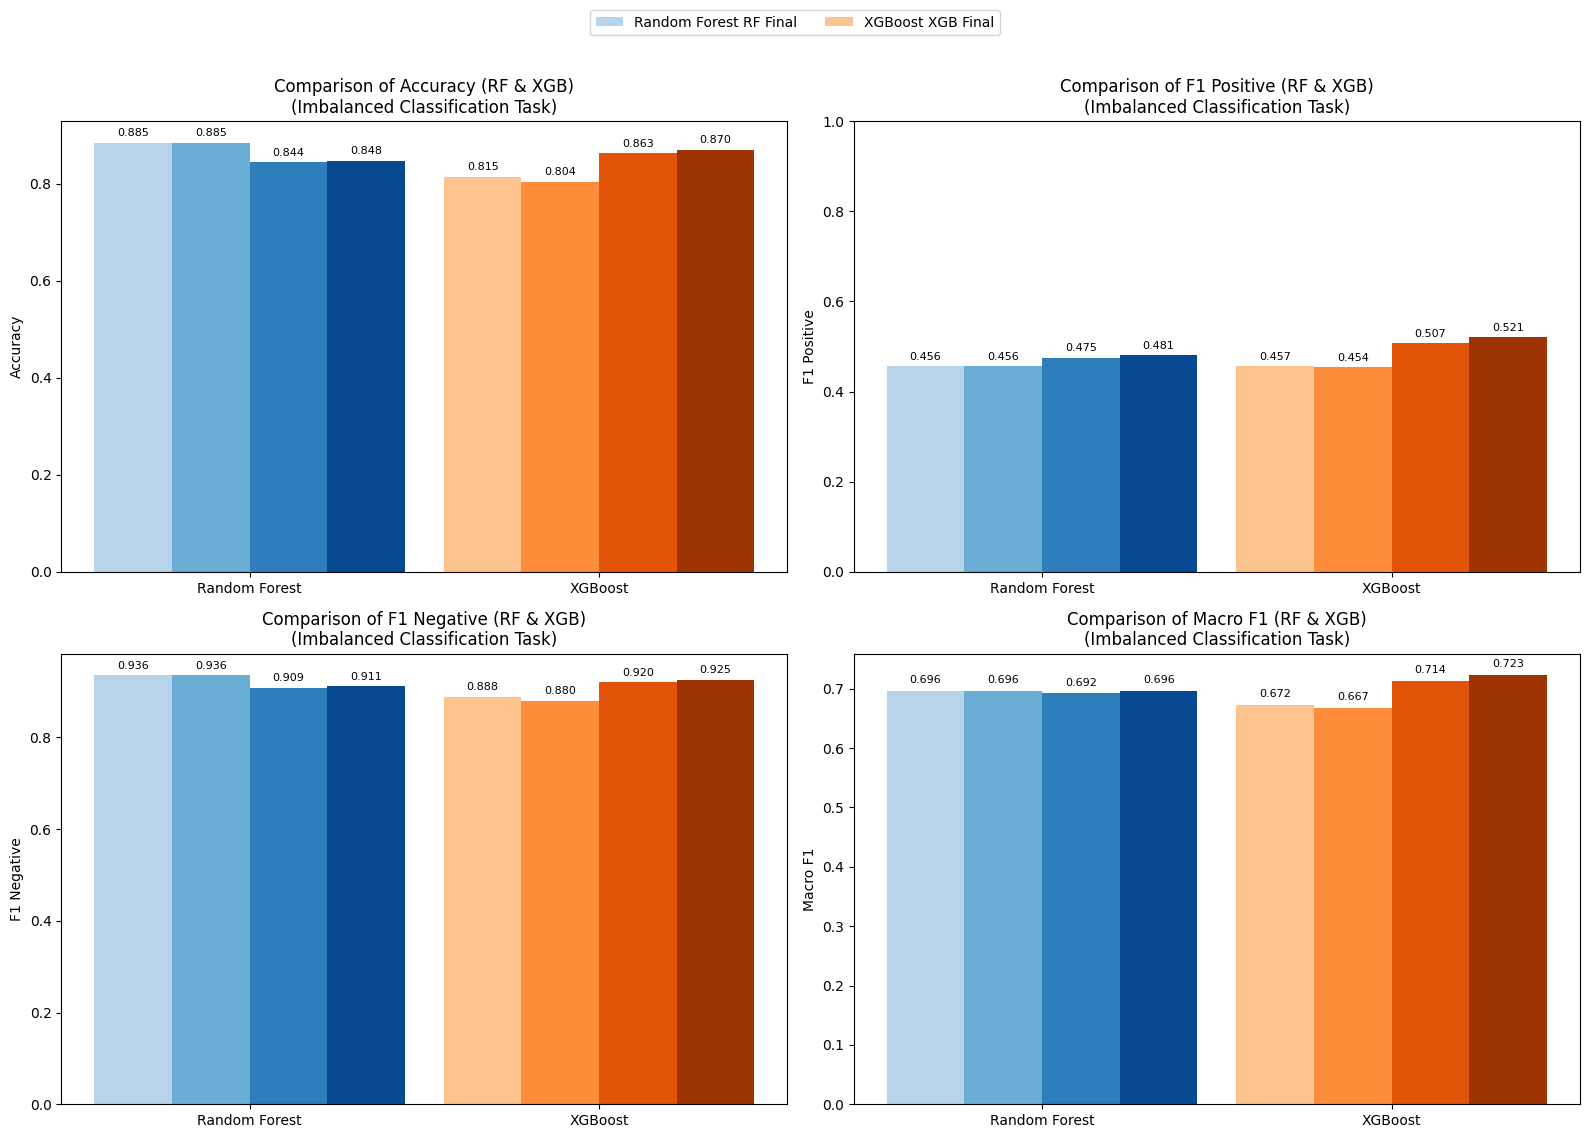

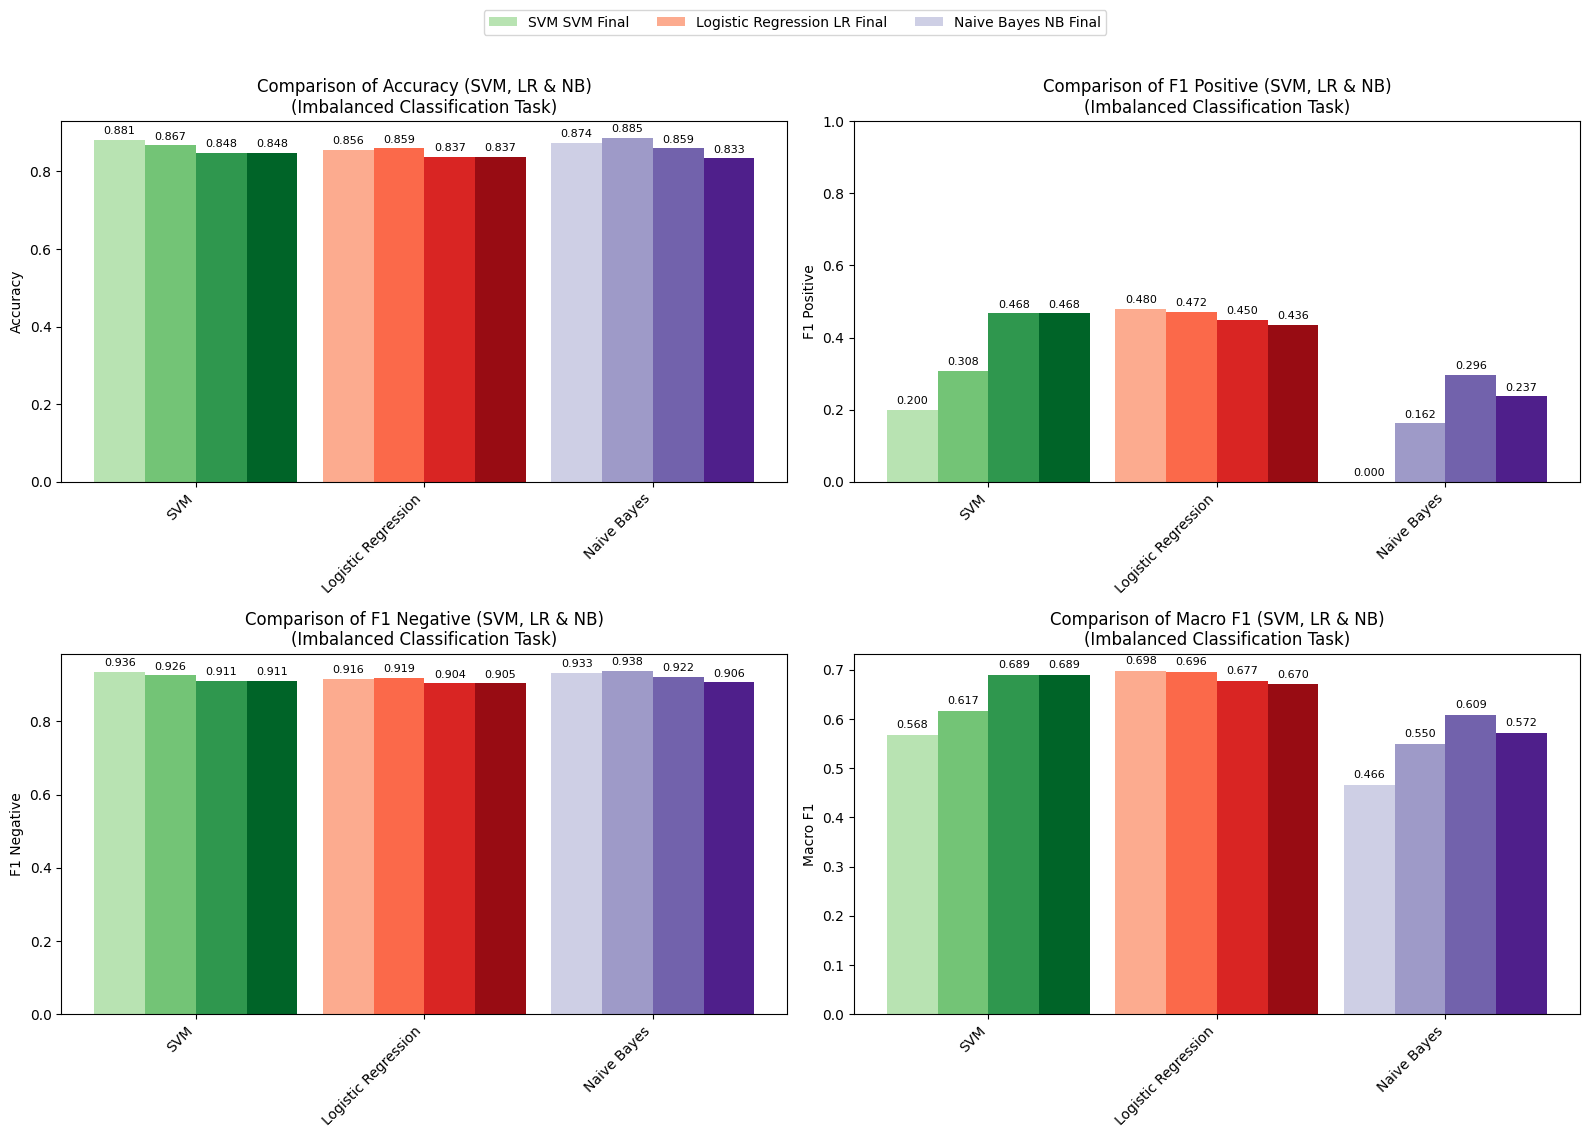

In [68]:
# Compare the five models (RF, SVM, LR, NB, XGB) and their tuned versions, including SMOTE for all

# Predictions for final models (trained on train+val)
models = {
    'RF Final': y_test_pred,
    'SVM Final': y_test_pred_svm,
    'LR Final': y_test_pred_lr,
    'NB Final': y_test_pred_nb,
    'XGB Final': y_test_pred_xgb,
    'RF Tuned': y_test_pred_rf_tuned,
    'SVM Tuned': y_test_pred_svm_tuned,
    'LR Tuned': y_test_pred_lr_tuned,
    'NB Tuned': y_test_pred_nb_tuned,
    'XGB Tuned': y_test_pred_xgb_tuned,
    'RF SMOTE Final': y_test_pred_rf_sm,
    'SVM SMOTE Final': y_test_pred_svm_sm,
    'LR SMOTE Final': y_test_pred_lr_sm,
    'NB SMOTE Final': y_test_pred_nb_sm,
    'XGB SMOTE Final': y_test_pred_xgb_sm,
    'RF SMOTE Tuned': y_test_pred_rf_tuned_sm,
    'SVM SMOTE Tuned': y_test_pred_svm_tuned_sm,
    'LR SMOTE Tuned': y_test_pred_lr_tuned_sm,
    'NB SMOTE Tuned': y_test_pred_nb_tuned_sm,
    'XGB SMOTE Tuned': y_test_pred_xgb_tuned_sm
}

# Compute metrics
results = {}
for name, preds in models.items():
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'F1 Positive': report['1']['f1-score'],
        'F1 Negative': report['0']['f1-score'],
        'Macro F1': report['macro avg']['f1-score']
    }

# Convert to DataFrame for plotting
df_results = pd.DataFrame(results).T
print(df_results)

# Group models by type
rf_models = ['RF Final', 'RF Tuned', 'RF SMOTE Final', 'RF SMOTE Tuned']
svm_models = ['SVM Final', 'SVM Tuned', 'SVM SMOTE Final', 'SVM SMOTE Tuned']
lr_models = ['LR Final', 'LR Tuned', 'LR SMOTE Final', 'LR SMOTE Tuned']
nb_models = ['NB Final', 'NB Tuned', 'NB SMOTE Final', 'NB SMOTE Tuned']
xgb_models = ['XGB Final', 'XGB Tuned', 'XGB SMOTE Final', 'XGB SMOTE Tuned']

# First plot: RF and XGB
model_groups_rf_xgb = [rf_models, xgb_models]
group_names_rf_xgb = ['Random Forest', 'XGBoost']
colors_rf_xgb = ['Blues', 'Oranges']

fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
metrics = ['Accuracy', 'F1 Positive', 'F1 Negative', 'Macro F1']

for i, metric in enumerate(metrics):
    ax = axes1[i//2, i%2]
    bar_width = 0.2
    for group_idx, (group, group_name, color_palette) in enumerate(zip(model_groups_rf_xgb, group_names_rf_xgb, colors_rf_xgb)):
        cmap = plt.get_cmap(color_palette)
        num_models = len(group)
        shades = [cmap(0.3 + j * 0.2) for j in range(num_models)]
        
        for j, model in enumerate(group):
            x_pos = group_idx * (num_models * bar_width + 0.1) + j * bar_width
            value = df_results.loc[model, metric]
            ax.bar(x_pos, value, width=bar_width, color=shades[j], label=f'{group_name} {model.split()[-2]} {model.split()[-1]}' if j == 0 else "")
    
    ax.set_title(f'Comparison of {metric} (RF & XGB)\n(Imbalanced Classification Task)', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticks([group_idx * (len(group) * bar_width + 0.1) + (len(group) - 1) * bar_width / 2 for group_idx in range(len(model_groups_rf_xgb))])
    ax.set_xticklabels(group_names_rf_xgb)
    
    if metric == 'F1 Positive':
        ax.set_ylim(0, 1)
    
    for j, (model, value) in enumerate(df_results[metric].items()):
        if model in [m for g in model_groups_rf_xgb for m in g]:
            group_idx = [g for g in model_groups_rf_xgb if model in g][0]
            model_idx = model_groups_rf_xgb.index(group_idx)
            sub_idx = group_idx.index(model)
            x_pos = model_idx * (len(group_idx) * bar_width + 0.1) + sub_idx * bar_width
            ax.text(x_pos, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

handles1, labels1 = ax.get_legend_handles_labels()
fig1.legend(handles1, labels1, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.95))
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# Second plot: SVM, LR, NB
model_groups_rest = [svm_models, lr_models, nb_models]
group_names_rest = ['SVM', 'Logistic Regression', 'Naive Bayes']
colors_rest = ['Greens', 'Reds', 'Purples']

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))

for i, metric in enumerate(metrics):
    ax = axes2[i//2, i%2]
    bar_width = 0.2
    for group_idx, (group, group_name, color_palette) in enumerate(zip(model_groups_rest, group_names_rest, colors_rest)):
        cmap = plt.get_cmap(color_palette)
        num_models = len(group)
        shades = [cmap(0.3 + j * 0.2) for j in range(num_models)]
        
        for j, model in enumerate(group):
            x_pos = group_idx * (num_models * bar_width + 0.1) + j * bar_width
            value = df_results.loc[model, metric]
            ax.bar(x_pos, value, width=bar_width, color=shades[j], label=f'{group_name} {model.split()[-2]} {model.split()[-1]}' if j == 0 else "")
    
    ax.set_title(f'Comparison of {metric} (SVM, LR & NB)\n(Imbalanced Classification Task)', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticks([group_idx * (len(group) * bar_width + 0.1) + (len(group) - 1) * bar_width / 2 for group_idx in range(len(model_groups_rest))])
    ax.set_xticklabels(group_names_rest, rotation=45, ha='right')
    
    if metric == 'F1 Positive':
        ax.set_ylim(0, 1)
    
    for j, (model, value) in enumerate(df_results[metric].items()):
        if model in [m for g in model_groups_rest for m in g]:
            group_idx = [g for g in model_groups_rest if model in g][0]
            model_idx = model_groups_rest.index(group_idx)
            sub_idx = group_idx.index(model)
            x_pos = model_idx * (len(group_idx) * bar_width + 0.1) + sub_idx * bar_width
            ax.text(x_pos, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

handles2, labels2 = ax.get_legend_handles_labels()
fig2.legend(handles2, labels2, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.95))
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [69]:
# sentences to be tested
test_sentences = [
    "Bahlil kinerjanya sangat bagus, programnya membantu rakyat.",
    "Harga pertalite naik terus, bikin susah masyarakat kecil.",
    "Menteri ini tidak becus kerja, cuma bisa omong doang.",
    "Terima kasih atas kebijakannya yang sangat bijak.",
    "Gw gak suka sama cara kerjanya, lambat banget."
]

# Model
model_objects = {
    # Random Forest
    'RF Final': rf_final,
    'RF Tuned': rf_tuned,
    'RF SMOTE': rf_sm,
    'RF SMOTE Tuned': rf_tuned_sm,
    
    # SVM
    'SVM Final': svm_final,
    'SVM Tuned': svm_tuned,
    'SVM SMOTE': svm_sm,
    'SVM SMOTE Tuned': svm_tuned_sm,
    
    # Logistic Regression
    'LR Final': lr_final,
    'LR Tuned': lr_tuned,
    'LR SMOTE': lr_sm,
    'LR SMOTE Tuned': lr_tuned_sm,
    
    # Naive Bayes
    'NB Final': nb_final,
    'NB Tuned': nb_tuned,
    'NB SMOTE': nb_sm,
    'NB SMOTE Tuned': nb_tuned_sm,
    
    # XGBoost
    'XGB Final': xgb_final,
    'XGB Tuned': xgb_tuned,
    'XGB SMOTE': xgb_sm,
    'XGB SMOTE Tuned': xgb_tuned_sm
}

# Preprocessing Data Test Data
target_vectorizer = vectorizer 

# Clean and vectorize the sentence
clean_sentences = [normalize_slang(clean_text(s), slang_dict) for s in test_sentences]
X_input_vec = target_vectorizer.transform(clean_sentences)

# Loop Prediction
results = {'Kalimat Asli': test_sentences}

for name, model in model_objects.items():
    try:
        # Prediction
        preds = model.predict(X_input_vec)
        
        # Conversion to text labels
        preds_text = ["Positif" if p == 1 else "Negatif" for p in preds]
        
        # Save to dictionary
        results[name] = preds_text
        
    except NameError:
        results[name] = ["Model Belum Dilatih"] * len(test_sentences)
    except Exception as e:
        results[name] = ["Error"] * len(test_sentences)


df_results = pd.DataFrame(results)


df_display = df_results.set_index('Kalimat Asli').T
display(df_display)

Kalimat Asli,"Bahlil kinerjanya sangat bagus, programnya membantu rakyat.","Harga pertalite naik terus, bikin susah masyarakat kecil.","Menteri ini tidak becus kerja, cuma bisa omong doang.",Terima kasih atas kebijakannya yang sangat bijak.,"Gw gak suka sama cara kerjanya, lambat banget."
RF Final,Negatif,Negatif,Negatif,Negatif,Negatif
RF Tuned,Negatif,Negatif,Negatif,Negatif,Negatif
RF SMOTE,Positif,Negatif,Negatif,Positif,Negatif
RF SMOTE Tuned,Positif,Negatif,Negatif,Positif,Positif
SVM Final,Negatif,Negatif,Negatif,Negatif,Negatif
SVM Tuned,Negatif,Negatif,Negatif,Negatif,Negatif
SVM SMOTE,Positif,Negatif,Negatif,Positif,Negatif
SVM SMOTE Tuned,Positif,Negatif,Negatif,Negatif,Negatif
LR Final,Negatif,Negatif,Negatif,Negatif,Negatif
LR Tuned,Negatif,Negatif,Negatif,Negatif,Negatif


In [ ]:
# Model
all_models = {
    # Random Forest
    'RF Final': rf_final,
    'RF Tuned': rf_tuned,
    'RF SMOTE': rf_sm,
    'RF SMOTE Tuned': rf_tuned_sm,
    
    # SVM
    'SVM Final': svm_final,
    'SVM Tuned': svm_tuned,
    'SVM SMOTE': svm_sm,
    'SVM SMOTE Tuned': svm_tuned_sm,
    
    # Logistic Regression
    'LR Final': lr_final,
    'LR Tuned': lr_tuned,
    'LR SMOTE': lr_sm,
    'LR SMOTE Tuned': lr_tuned_sm,
    
    # Naive Bayes
    'NB Final': nb_final,
    'NB Tuned': nb_tuned,
    'NB SMOTE': nb_sm,
    'NB SMOTE Tuned': nb_tuned_sm,
    
    # XGBoost
    'XGB Final': xgb_final,
    'XGB Tuned': xgb_tuned,
    'XGB SMOTE': xgb_sm,
    'XGB SMOTE Tuned': xgb_tuned_sm
}

# 2. Vectorizer
model_package = {
    'vectorizer': vectorizer_final,  
    'slang_dict': slang_dict,
    'models_dict': all_models   
}

# 3. Save
filename = 'all_sentiment_models.pkl'

try:
    with open(filename, 'wb') as file:
        pickle.dump(model_package, file)
    print(f"Sukses! 20 Model berhasil disimpan ke '{filename}'")
except Exception as e:
    print(f"Gagal menyimpan: {e}")

Sukses! 20 Model berhasil disimpan ke 'all_sentiment_models.pkl'


In [73]:
# Load the full monolithic package
with open('all_sentiment_models.pkl', 'rb') as f:
    package = pickle.load(f)

# Verify the keys exist before extracting
print("Package keys:", list(package.keys()))
print("Available models:", list(package['models_dict'].keys()))

# Extract only what serving needs
lean_package = {
    'model': package['models_dict']['RF SMOTE Tuned'],  # our chosen model
    'vectorizer': package['vectorizer'],                 # TF-IDF vectorizer
    'slang_dict': package['slang_dict']                  # normalization dict
}

# Save the lean file — this is what goes into the Space
with open('model.pkl', 'wb') as f:
    pickle.dump(lean_package, f)

print("✅ model.pkl saved successfully")

# Check the file size — important for HuggingFace's limits
import os
size_mb = os.path.getsize('model.pkl') / (1024 * 1024)
print(f"File size: {size_mb:.2f} MB")

Package keys: ['vectorizer', 'slang_dict', 'models_dict']
Available models: ['RF Final', 'RF Tuned', 'RF SMOTE', 'RF SMOTE Tuned', 'SVM Final', 'SVM Tuned', 'SVM SMOTE', 'SVM SMOTE Tuned', 'LR Final', 'LR Tuned', 'LR SMOTE', 'LR SMOTE Tuned', 'NB Final', 'NB Tuned', 'NB SMOTE', 'NB SMOTE Tuned', 'XGB Final', 'XGB Tuned', 'XGB SMOTE', 'XGB SMOTE Tuned']
✅ model.pkl saved successfully
File size: 7.58 MB
